# 03 第2 Linear における logits error の伝播

今回の中心は

$$
\Delta L=\Delta H W_2^{\mathsf T}
$$

と

$$
\|\Delta L\|_F\le \|\Delta H\|_F\|W_2\|_2
$$

です。

01・02で確認済みの

$$
\Delta Z_1=X\Delta W_1^{\mathsf T},
\qquad
\|\Delta H\|_F\le\|\Delta Z_1\|_F
\le\|X\|_F\|\Delta W_1\|_2
$$

と結合して、

$$
\boxed{
\|\Delta L\|_F
\le
\|X\|_F\|\Delta W_1\|_2\|W_2\|_2
}
$$

まで確認します。

今回は classification margin、argmax、accuracy、Fashion-MNIST、fine-tuning、
第2 Linear の TT 圧縮、TT-SVD / TT-rounding の再実装には進みません。


## 1. 実行環境

新しい変数は、初出時に以下の6項目で説明します。

1. 何を意味する変数か
2. 数式上の定義・対応
3. shape
4. 各軸の意味
5. 何から計算されるか
6. 何のために使うか

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `dtype` | Tensor の浮動小数点型 | 数式対応なし | scalar setting | 軸なし | `torch.float64` を指定 | 丸め誤差を抑えた数値検証 |
| `device` | Tensor を置く計算デバイス | 数式対応なし | scalar setting | 軸なし | `torch.device("cpu")` | CPU 上で再現可能に実行 |
| `rtol` | 相対許容誤差 | 数式対応なし | scalar | 軸なし | 手動設定 | `assert_close` の恒等式検証 |
| `atol` | 絶対許容誤差 | 数式対応なし | scalar | 軸なし | 手動設定 | `assert_close` の恒等式検証 |
| `inequality_atol` | 不等式用の微小許容誤差 | 数式対応なし | scalar | 軸なし | 手動設定 | 浮動小数点誤差を考慮した `assert` |


In [42]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from torch.testing import assert_close

torch.manual_seed(0)

dtype = torch.float64
device = torch.device("cpu")

rtol = 1e-10
atol = 1e-12
inequality_atol = 1e-12


## 2. 2層 MLP と誤差の定義

Dense model:

$$
Z_1=XW_1^{\mathsf T}+b_1,
\qquad
H=\operatorname{ReLU}(Z_1),
\qquad
L=HW_2^{\mathsf T}+b_2.
$$

Compressed model:

$$
\widetilde Z_1=X\widetilde W_1^{\mathsf T}+b_1,
\qquad
\widetilde H=\operatorname{ReLU}(\widetilde Z_1),
\qquad
\widetilde L=\widetilde H W_2^{\mathsf T}+b_2.
$$

圧縮するのは第1 Linear の weight だけです。$W_2,b_1,b_2$ は両モデルで共通です。

$$
\Delta W_1=\widetilde W_1-W_1,
\quad
\Delta Z_1=\widetilde Z_1-Z_1,
\quad
\Delta H=\widetilde H-H,
\quad
\Delta L=\widetilde L-L.
$$


## 3. Toy model と shape

今回は、

$$
B=4,\qquad d=6,\qquad h=5,\qquad c=3
$$

とします。

`w1_tilde` は TT-SVD を再実装せず、

$$
\widetilde W_1=W_1+\Delta W_1
$$

という toy approximation として作ります。

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `B` | batch size | $B$ | scalar | 軸なし | 固定値 4 | batch 軸の大きさ |
| `d` | input dimension | $d$ | scalar | 軸なし | 固定値 6 | 入力特徴数 |
| `h` | hidden dimension | $h$ | scalar | 軸なし | 固定値 5 | hidden unit 数 |
| `c` | output / class dimension | $c$ | scalar | 軸なし | 固定値 3 | logits の出力次元 |
| `x` | 入力 batch | $X$ | $(B,d)$ | axis 0: batch、axis 1: input feature | `torch.randn` | 両モデルに共通入力を与える |
| `w1` | dense 第1 Linear の weight | $W_1$ | $(h,d)$ | axis 0: hidden、axis 1: input | `torch.randn` | dense 側の第1層変換 |
| `b1` | 第1 Linear の共通 bias | $b_1$ | $(h,)$ | axis 0: hidden | `torch.randn` | dense / compressed の第1層で共通使用 |
| `w2` | 圧縮しない第2 Linear の weight | $W_2$ | $(c,h)$ | axis 0: output/class、axis 1: hidden | `torch.randn` | hidden error を logits error へ写す |
| `b2` | 第2 Linear の共通 bias | $b_2$ | $(c,)$ | axis 0: output/class | `torch.randn` | dense / compressed の第2層で共通使用 |
| `perturbation_scale` | 第1層 weight error の大きさ | $\alpha$ | scalar | 軸なし | 固定値 0.05 | toy approximation の誤差量を調整 |
| `delta_w1` | 第1層 weight approximation error | $\Delta W_1$ | $(h,d)$ | axis 0: hidden、axis 1: input | `perturbation_scale * random matrix` | TT truncation error の toy 代理 |
| `w1_tilde` | compressed 第1層 weight | $\widetilde W_1=W_1+\Delta W_1$ | $(h,d)$ | axis 0: hidden、axis 1: input | `w1 + delta_w1` | compressed model の第1層に使う |
| `delta_w1_from_weights` | weight の差から再計算した誤差 | $\widetilde W_1-W_1$ | $(h,d)$ | axis 0: hidden、axis 1: input | `w1_tilde - w1` | $\Delta W_1=\widetilde W_1-W_1$ をコード上で検証 |


In [43]:
B, d, h, c = 4, 6, 5, 3

x = torch.randn(B, d, dtype=dtype, device=device)

w1 = torch.randn(h, d, dtype=dtype, device=device)
b1 = torch.randn(h, dtype=dtype, device=device)

w2 = torch.randn(c, h, dtype=dtype, device=device)
b2 = torch.randn(c, dtype=dtype, device=device)

perturbation_scale = 0.05
delta_w1 = perturbation_scale * torch.randn(
    h, d, dtype=dtype, device=device
)
w1_tilde = w1 + delta_w1

# 定義 Delta_W1 = W1_tilde - W1 を別計算して確認する。
delta_w1_from_weights = w1_tilde - w1

assert x.shape == (B, d)
assert w1.shape == (h, d)
assert b1.shape == (h,)
assert delta_w1.shape == (h, d)
assert w1_tilde.shape == (h, d)
assert delta_w1_from_weights.shape == (h, d)
assert w2.shape == (c, h)
assert b2.shape == (c,)

assert_close(
    delta_w1_from_weights,
    delta_w1,
    rtol=rtol,
    atol=atol,
)


## 4. 既習部分：第1 Linear → ReLU

01・02で学習済みなので、ここは完成コードとして再利用します。

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `z1` | dense 側 pre-activation | $Z_1=XW_1^\mathsf T+b_1$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `x`, `w1`, `b1` | dense 第1 Linear の出力 |
| `z1_tilde` | compressed 側 pre-activation | $\widetilde Z_1=X\widetilde W_1^\mathsf T+b_1$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `x`, `w1_tilde`, `b1` | compressed 第1 Linear の出力 |
| `delta_z1` | 第1 Linear output error | $\Delta Z_1=\widetilde Z_1-Z_1$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `z1_tilde - z1` | 第1層の forward error を測る |
| `delta_z1_from_formula` | 理論式から計算した第1層誤差 | $X\Delta W_1^\mathsf T$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `x @ delta_w1.T` | $\Delta Z_1=X\Delta W_1^\mathsf T$ の検証 |
| `h_dense` | dense hidden activation | $H=\operatorname{ReLU}(Z_1)$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `relu(z1)` | 第2 Linear への dense 入力 |
| `h_tilde` | compressed hidden activation | $\widetilde H=\operatorname{ReLU}(\widetilde Z_1)$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `relu(z1_tilde)` | 第2 Linear への compressed 入力 |
| `delta_h` | hidden activation error | $\Delta H=\widetilde H-H$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `h_tilde - h_dense` | ReLU 後の誤差を測る |
| `delta_z1_fro` | 第1 Linear error の Frobenius norm | $\|\Delta Z_1\|_F$ | scalar | 軸なし | `delta_z1` | ReLU 前の誤差量 |
| `delta_h_fro` | hidden error の Frobenius norm | $\|\Delta H\|_F$ | scalar | 軸なし | `delta_h` | ReLU 後の誤差量 |


In [44]:
z1 = x @ w1.T + b1
z1_tilde = x @ w1_tilde.T + b1

delta_z1 = z1_tilde - z1
delta_z1_from_formula = x @ delta_w1.T

assert_close(
    delta_z1,
    delta_z1_from_formula,
    rtol=rtol,
    atol=atol,
)

h_dense = torch.relu(z1)
h_tilde = torch.relu(z1_tilde)
delta_h = h_tilde - h_dense

assert z1.shape == (B, h)
assert z1_tilde.shape == (B, h)
assert delta_z1.shape == (B, h)
assert h_dense.shape == (B, h)
assert h_tilde.shape == (B, h)
assert delta_h.shape == (B, h)

delta_z1_fro = torch.linalg.matrix_norm(delta_z1, ord="fro")
delta_h_fro = torch.linalg.matrix_norm(delta_h, ord="fro")

assert delta_h_fro <= delta_z1_fro + inequality_atol


## 5. 第2 Linear の logits error 恒等式

$$
L=HW_2^{\mathsf T}+b_2,
\qquad
\widetilde L=\widetilde H W_2^{\mathsf T}+b_2.
$$

したがって、

$$
\begin{aligned}
\Delta L
&=\widetilde L-L\\
&=
(\widetilde H W_2^{\mathsf T}+b_2)
-
(HW_2^{\mathsf T}+b_2)\\
&=
(\widetilde H-H)W_2^{\mathsf T}\\
&=
\Delta H W_2^{\mathsf T}.
\end{aligned}
$$

共通の bias は

$$
b_2-b_2=0
$$

なので差分から消えます。

shape は、

$$
\underbrace{\Delta H}_{B\times h}
\underbrace{W_2^{\mathsf T}}_{h\times c}
=
\underbrace{\Delta L}_{B\times c}.
$$### 新しい変数

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `logits` | dense model の logits | $L=HW_2^\mathsf T+b_2$ | $(B,c)$ | axis 0: batch、axis 1: output/class | `h_dense`, `w2`, `b2` | 基準となる最終出力 |
| `logits_tilde` | compressed model の logits | $\widetilde L=\widetilde HW_2^\mathsf T+b_2$ | $(B,c)$ | axis 0: batch、axis 1: output/class | `h_tilde`, `w2`, `b2` | 圧縮後モデルの最終出力 |
| `delta_l` | logits error | $\Delta L=\widetilde L-L$ | $(B,c)$ | axis 0: batch、axis 1: output/class | `logits_tilde - logits` | 最終出力に伝播した誤差を測る |
| `delta_l_from_formula` | 理論式から計算した logits error | $\Delta H W_2^\mathsf T$ | $(B,c)$ | axis 0: batch、axis 1: output/class | `delta_h @ w2.T` | $\Delta L=\Delta H W_2^\mathsf T$ の検証 |
| `logits_identity_error` | 恒等式の最大絶対誤差 | $\max|\Delta L-\Delta H W_2^\mathsf T|$ | scalar | 軸なし | `delta_l` と `delta_l_from_formula` | 数値誤差の大きさを確認 |


In [45]:
# TODO 1:
# logits, logits_tilde, delta_l を計算してください。
logits = h_dense@w2.T + b2
logits_tilde = h_tilde@w2.T + b2
delta_l = logits_tilde - logits
# さらに Delta_L = Delta_H W2^T を別計算し、
delta_l_from_formula = delta_h@w2.T
# 両者の一致と shape を確認してください。
assert_close(delta_l, delta_l_from_formula, rtol=rtol, atol=atol)

### ヒント

- dense 側は $L=HW_2^\mathsf T+b_2$
- compressed 側は $\widetilde L=\widetilde H W_2^\mathsf T+b_2$
- $\Delta L$ は **compressed − dense**
- 右辺は $\Delta H W_2^\mathsf T$
- shape は $(B,h)(h,c)=(B,c)$


### 検証


In [46]:
assert logits.shape == (B, c)
assert logits_tilde.shape == (B, c)
assert delta_l.shape == (B, c)
assert delta_l_from_formula.shape == (B, c)

assert_close(
    delta_l,
    delta_l_from_formula,
    rtol=rtol,
    atol=atol,
)

logits_identity_error = (
    delta_l - delta_l_from_formula
).abs().max()

print(
    "max |Delta_L - Delta_H W2^T| =",
    f"{logits_identity_error.item():.12e}",
)


max |Delta_L - Delta_H W2^T| = 3.608224830032e-16


## 6. spectral norm と最大特異値

$W_2\in\mathbb R^{c\times h}$ の spectral norm は、

$$
\|W_2\|_2
=
\sup_{x\neq0}
\frac{\|W_2x\|_2}{\|x\|_2}
$$

です。

つまり、hidden-space のベクトルを第2 Linear が最大で何倍まで伸ばせるかを表します。

今回の toy model では

$$
c=3,\qquad h=5
$$

なので、

$$
W_2\in\mathbb R^{3\times5}
$$

は正方行列ではなく長方形行列です。

SVD を

$$
W_2=U\Sigma V^{\mathsf T}
$$

と書くと、

$$
U\in\mathbb R^{3\times3},
\qquad
\Sigma\in\mathbb R^{3\times5},
\qquad
V\in\mathbb R^{5\times5}
$$

です。特異値の個数は

$$
r=\min(c,h)=\min(3,5)=3
$$

です。

$\|x\|_2=1$ とし、

$$
z=V^{\mathsf T}x\in\mathbb R^{5},
\qquad
\|z\|_2=1
$$

と置くと、$U,V$ は直交行列なので Euclidean norm を変えず、

$$
\|W_2x\|_2
=
\|\Sigma z\|_2
$$

です。長方形の $\Sigma$ に対しては、

$$
\Sigma z
=
\begin{bmatrix}
\sigma_1 z_1\\
\sigma_2 z_2\\
\sigma_3 z_3
\end{bmatrix}
\in\mathbb R^{3}
$$

となります。つまり $\Sigma$ の対角成分に対応する先頭 $r=3$ 座標だけが特異値で伸縮され、残りの入力座標 $z_4,z_5$ は $\Sigma z$ の中では寄与しません（$0$ になる）。

したがって、

$$
\begin{aligned}
\|\Sigma z\|_2^2
&=
\sum_{i=1}^{3}
\sigma_i^2 z_i^2\\
&\le
\sigma_1^2
\sum_{i=1}^{3}
z_i^2\\
&\le
\sigma_1^2
\sum_{i=1}^{5}
z_i^2\\
&=
\sigma_1^2
\|z\|_2^2\\
&=
\sigma_1^2.
\end{aligned}
$$

よって、

$$
\|\Sigma z\|_2
\le
\sigma_1.
$$

さらに、最大特異値に対応する右特異ベクトル

$$
v_1\in\mathbb R^{5}
$$

を選べば、

$$
W_2v_1
=
\sigma_1u_1
$$

となるため、

$$
\|W_2v_1\|_2
=
\sigma_1.
$$

したがって、

$$
\boxed{
\|W_2\|_2
=
\sigma_{\max}(W_2)
=
\sigma_1(W_2)
}
$$

です。

一般の形としては、$r=\min(c,h)$ とおけば、

$$
\begin{aligned}
\|\Sigma z\|_2^2
&=
\sum_{i=1}^{r}\sigma_i^2 z_i^2\\
&\le
\sigma_1^2
\sum_{i=1}^{r}z_i^2\\
&\le
\sigma_1^2
\sum_{i=1}^{h}z_i^2\\
&=
\sigma_1^2.
\end{aligned}
$$

と書けます。

転置しても特異値は変わらないため、

$$
\|W_2^{\mathsf T}\|_2=\|W_2\|_2.
$$

### 新しい変数

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `w2_singular_values` | $W_2$ の特異値列 | $(\sigma_1,\sigma_2,\ldots)$ | `(min(c, h),)` | axis 0: singular-value index | `torch.linalg.svdvals(w2)` | 最大特異値を確認 |
| `w2_spectral` | 第2 Linear の spectral norm | $\|W_2\|_2$ | scalar | 軸なし | `w2` の matrix 2-norm | hidden error の最大増幅率を表す |


In [47]:
# TODO 2:
# W2 の spectral norm と特異値を計算し、
w2_spectral = torch.linalg.matrix_norm(w2, ord=2)
w2_singular_values = torch.linalg.svdvals(w2)
# spectral norm = 最大特異値 を確認してください。
assert_close(
    w2_spectral,
    w2_singular_values.max(),
    rtol=rtol,
    atol=atol,
)


### ヒント

- 特異値は `torch.linalg.svdvals`
- spectral norm は `torch.linalg.matrix_norm(..., ord=2)`
- 比較するのは $\|W_2\|_2$ と最大特異値


### 検証


In [48]:
assert w2_singular_values.shape == (min(c, h),)

assert_close(
    w2_spectral,
    w2_singular_values.max(),
    rtol=rtol,
    atol=atol,
)

print(f"||W2||_2          = {w2_spectral.item():.12e}")
print(
    "max singular value =",
    f"{w2_singular_values.max().item():.12e}",
)


||W2||_2          = 4.100457731042e+00
max singular value = 4.100457731042e+00


## 7. 第2 Linear の logits error 上界

恒等式、

$$
\Delta L=\Delta H W_2^{\mathsf T}
$$

から、

$$
\|\Delta L\|_F
=
\|\Delta H W_2^{\mathsf T}\|_F.
$$

行列積に対する評価、

$$
\|AB\|_F
\le
\|A\|_F\|B\|_2
$$

を使うと、

$$
\|\Delta L\|_F
\le
\|\Delta H\|_F
\|W_2^{\mathsf T}\|_2.
$$

したがって、

$$
\boxed{
\|\Delta L\|_F
\le
\|\Delta H\|_F
\|W_2\|_2
}
$$

です。

行ごとに見ると、第 $n$ sample に対して、

$$
\delta l_n^{\mathsf T}
=
W_2\delta h_n^{\mathsf T}
$$

なので、

$$
\|\delta l_n\|_2
\le
\|W_2\|_2\|\delta h_n\|_2.
$$

これを二乗して全 batch で足すことで同じ Frobenius norm 上界が得られます。### 新しい変数

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `delta_l_fro` | 実測 logits error の大きさ | $\|\Delta L\|_F$ | scalar | 軸なし | `delta_l` の Frobenius norm | 第2 Linear 後の実測誤差を測る |
| `logits_upper_bound` | 第2 Linear の logits error 上界 | $\|\Delta H\|_F\|W_2\|_2$ | scalar | 軸なし | `delta_h_fro * w2_spectral` | $\|\Delta L\|_F$ の理論上界として比較 |


In [49]:
# TODO 3:
# ||Delta_L||_F と ||Delta_H||_F ||W2||_2 を計算し、
# logits error の上界を確認してください。

# 実測 logits error の Frobenius norm
# delta_l は
# ΔL = L_tilde - L
# に対応する。
# shape: (B, c)
# axis 0: batch sample
# axis 1: output / class
# dense model と compressed model を実際に forward して得た
# logits の差から計算する。
delta_l_fro = torch.linalg.matrix_norm(delta_l, ord="fro")

# hidden activation error の Frobenius norm
# delta_h は
# ΔH = H_tilde - H
# に対応する。
# shape: (B, h)
# axis 0: batch sample
# axis 1: hidden unit
delta_h_fro = torch.linalg.matrix_norm(delta_h, ord="fro")

# 第2 Linear の spectral norm
# w2 は W2 に対応する。
# shape: (c, h)
# axis 0: output / class
# axis 1: hidden unit
# ord=2 は Frobenius norm ではなく spectral norm を返す。
# w2_spectral = ||W2||_2
# = sigma_max(W2)
# 第2 Linear が hidden error を最悪の場合に何倍へ
# 増幅し得るかを表す。
w2_spectral = torch.linalg.matrix_norm(w2, ord=2)

# 第2 Linear による logits error の理論上界
# ||ΔL||_F <= ||ΔH||_F ||W2||_2
logits_upper_bound = delta_h_fro * w2_spectral

# 実測 logits error が理論上界を超えないことを確認する。
assert delta_l_fro <= logits_upper_bound + inequality_atol

print(f"||ΔH||_F                 = {delta_h_fro.item():.12e}")
print(f"||W2||_2                 = {w2_spectral.item():.12e}")
print(f"||ΔL||_F                 = {delta_l_fro.item():.12e}")
print(
    "||ΔH||_F ||W2||_2        =",
    f"{logits_upper_bound.item():.12e}",
)
print(
    "bound holds              =",
    bool(delta_l_fro <= logits_upper_bound + inequality_atol),
)


### ヒント

- 左辺は `delta_l` の Frobenius norm
- 右辺は `delta_h_fro * w2_spectral`
- 不等式は丸め誤差を考慮して `inequality_atol` を使う


### 検証


In [50]:
# TODO 3 の結果を再確認する
assert float(delta_l_fro) <= float(logits_upper_bound) + inequality_atol
print("TODO 3 verification OK")


||Delta_H||_F             = 3.306492197740e-01
||W2||_2                  = 4.100457731042e+00
||Delta_L||_F             = 4.669371802503e-01
||Delta_H||_F ||W2||_2 = 1.355813149485e+00
bound holds             = True


## 8. 01・02と結合した最終上界

既習の、

$$
\|\Delta H\|_F
\le
\|\Delta Z_1\|_F
$$

と、

$$
\|\Delta Z_1\|_F
\le
\|X\|_F\|\Delta W_1\|_2
$$

を、第2 Linear の上界とつなげます。

$$
\begin{aligned}
\|\Delta L\|_F
&\le
\|\Delta H\|_F\|W_2\|_2\\
&\le
\|\Delta Z_1\|_F\|W_2\|_2\\
&\le
\|X\|_F\|\Delta W_1\|_2\|W_2\|_2.
\end{aligned}
$$

したがって、

$$
\boxed{
\|\Delta L\|_F
\le
\|X\|_F
\|\Delta W_1\|_2
\|W_2\|_2
}
$$

です。

$\|W_2\|_2\ge0$ なので、不等式に掛けても向きは変わりません。### 新しい変数

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `x_fro` | 入力 batch の Frobenius norm | $\|X\|_F$ | scalar | 軸なし | `x` | 第1層誤差上界を作る |
| `delta_w1_spectral` | 第1層 weight error の spectral norm | $\|\Delta W_1\|_2$ | scalar | 軸なし | `delta_w1` | 第1層の最大誤差増幅率を表す |
| `z1_upper_bound` | 第1 Linear output error の上界 | $\|X\|_F\|\Delta W_1\|_2$ | scalar | 軸なし | `x_fro * delta_w1_spectral` | $\|\Delta Z_1\|_F$ と比較 |
| `full_upper_bound` | 2層 MLP 全体の logits error 上界 | $\|X\|_F\|\Delta W_1\|_2\|W_2\|_2$ | scalar | 軸なし | `z1_upper_bound * w2_spectral` | $\|\Delta L\|_F$ と比較する最終上界 |


In [51]:
# TODO 4:
# 01・02の上界と今回の第2 Linear の上界をつなぎ、
# ||Delta_L||_F <= ||X||_F ||Delta_W1||_2 ||W2||_2
# を数値的に確認してください。
x_fro = torch.linalg.vector_norm(x)
delta_w1_spectral = torch.linalg.matrix_norm(delta_w1, ord=2)
z1_upper_bound = x_fro * delta_w1_spectral
full_upper_bound = z1_upper_bound * w2_spectral

assert float(delta_z1_fro) <= float(z1_upper_bound) + inequality_atol
assert float(delta_h_fro) <= float(delta_z1_fro) + inequality_atol
assert float(delta_l_fro) <= float(logits_upper_bound) + inequality_atol
assert float(delta_l_fro) <= float(full_upper_bound) + inequality_atol


### ヒント

- `x_fro` は $\|X\|_F$
- `delta_w1_spectral` は $\|\Delta W_1\|_2$
- 第1層上界はその積
- 最終上界はさらに $\|W_2\|_2$ を掛ける


### 検証


In [52]:
assert delta_z1_fro <= z1_upper_bound + inequality_atol
assert delta_h_fro <= delta_z1_fro + inequality_atol
assert delta_l_fro <= logits_upper_bound + inequality_atol
assert delta_l_fro <= full_upper_bound + inequality_atol

print(f"||Delta_Z1||_F                 = {delta_z1_fro.item():.12e}")
print(f"||X||_F ||Delta_W1||_2         = {z1_upper_bound.item():.12e}")
print(f"||Delta_H||_F                  = {delta_h_fro.item():.12e}")
print(f"||Delta_L||_F                  = {delta_l_fro.item():.12e}")
print(
    "||X||_F ||Delta_W1||_2 ||W2||_2 =",
    f"{full_upper_bound.item():.12e}",
)


||Delta_Z1||_F                 = 4.662638322511e-01
||X||_F ||Delta_W1||_2         = 7.309086424606e-01
||Delta_H||_F                  = 3.306492197740e-01
||Delta_L||_F                  = 4.669371802503e-01
||X||_F ||Delta_W1||_2 ||W2||_2 = 2.997059993663e+00


## 9. 実測値と上界を比較する

最後に以下を並べます。

1. $\|\Delta Z_1\|_F$
2. $\|X\|_F\|\Delta W_1\|_2$
3. $\|\Delta H\|_F$
4. $\|\Delta L\|_F$
5. $\|\Delta H\|_F\|W_2\|_2$
6. $\|X\|_F\|\Delta W_1\|_2\|W_2\|_2$### 新しい変数

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `logits_bound_ratio` | 第2層上界に対する実測誤差の比率 | $\|\Delta L\|_F / (\|\Delta H\|_F\|W_2\|_2)$ | scalar | 軸なし | `delta_l_fro / logits_upper_bound` | 第2 Linear の上界がどれだけ tight か見る |
| `full_bound_ratio` | 最終上界に対する実測誤差の比率 | $\|\Delta L\|_F / (\|X\|_F\|\Delta W_1\|_2\|W_2\|_2)$ | scalar | 軸なし | `delta_l_fro / full_upper_bound` | 全体上界の余裕を評価 |
| `rows` | 表示用の名前と値の組 | 数式対応なし | Python list | 各要素: `(name, value)` | 各 norm / bound | 実測値と上界を見やすく表示 |


In [53]:
# TODO 5:
# 各段階の実測値・上界・実測値/上界の比率を
# 見やすく表示してください。
assert float(logits_upper_bound) > 0.0
assert float(full_upper_bound) > 0.0

logits_bound_ratio = delta_l_fro / logits_upper_bound
full_bound_ratio = delta_l_fro / full_upper_bound

rows = [
    ("||Delta_Z1||_F", float(delta_z1_fro)),
    ("||X||_F ||Delta_W1||_2", float(z1_upper_bound)),
    ("||Delta_H||_F", float(delta_h_fro)),
    ("||Delta_L||_F", float(delta_l_fro)),
    ("||Delta_H||_F ||W2||_2", float(logits_upper_bound)),
    ("||X||_F ||Delta_W1||_2 ||W2||_2", float(full_upper_bound)),
]

print("=== measured / bound ===")
for name, value in rows:
    print(f"{name:<42} {value:.12e}")

print("\n=== ratios (measured / bound) ===")
print(f"logits bound ratio = {float(logits_bound_ratio):.6f}")
print(f"full bound ratio   = {float(full_bound_ratio):.6f}")


=== measured / bound ===
||Delta_Z1||_F                             4.662638322511e-01
||X||_F ||Delta_W1||_2                     7.309086424606e-01
||Delta_H||_F                              3.306492197740e-01
||Delta_L||_F                              4.669371802503e-01
||Delta_H||_F ||W2||_2                     1.355813149485e+00
||X||_F ||Delta_W1||_2 ||W2||_2            2.997059993663e+00

=== ratios (measured / bound) ===
logits bound ratio = 0.344396
full bound ratio   = 0.155798


### ヒント

- 第2層上界に対する比率：$\|\Delta L\|_F / (\|\Delta H\|_F\|W_2\|_2)$
- 最終上界に対する比率：$\|\Delta L\|_F / (\|X\|_F\|\Delta W_1\|_2\|W_2\|_2)$
- 0除算が起きないことも確認する


### 検証


In [54]:
assert logits_upper_bound > 0.0
assert full_upper_bound > 0.0

assert logits_bound_ratio <= 1.0 + inequality_atol
assert full_bound_ratio <= 1.0 + inequality_atol

rows = [
    ("||Delta_Z1||_F", delta_z1_fro.item()),
    ("||X||_F ||Delta_W1||_2", z1_upper_bound.item()),
    ("||Delta_H||_F", delta_h_fro.item()),
    ("||Delta_L||_F", delta_l_fro.item()),
    ("||Delta_H||_F ||W2||_2", logits_upper_bound.item()),
    (
        "||X||_F ||Delta_W1||_2 ||W2||_2",
        full_upper_bound.item(),
    ),
]

for name, value in rows:
    print(f"{name:<42} {value:.12e}")

print(f"\nlogits bound ratio = {logits_bound_ratio.item():.6f}")
print(f"full bound ratio   = {full_bound_ratio.item():.6f}")


||Delta_Z1||_F                             4.662638322511e-01
||X||_F ||Delta_W1||_2                     7.309086424606e-01
||Delta_H||_F                              3.306492197740e-01
||Delta_L||_F                              4.669371802503e-01
||Delta_H||_F ||W2||_2                     1.355813149485e+00
||X||_F ||Delta_W1||_2 ||W2||_2            2.997059993663e+00

logits bound ratio = 0.344396
full bound ratio   = 0.155798


## 10. perturbation scale を変えて誤差伝播を見る

ここでは TT-rank 自体は変えず、

$$
\Delta W_1(\alpha)=\alpha E
$$

とします。

$E$ は固定した perturbation direction、$\alpha$ が `perturbation_scale` です。

同じ方向 $E$ のまま $\alpha$ だけを変えることで、

$$
\|\Delta W_1\|_2,
\quad
\|\Delta Z_1\|_F,
\quad
\|\Delta H\|_F,
\quad
\|\Delta L\|_F,
\quad
\|X\|_F\|\Delta W_1\|_2\|W_2\|_2
$$

がどう変わるかを比較します。

$\alpha=0$ では、

$$
\|\Delta L(0)\|_F=0,
\qquad
\|X\|_F\|\Delta W_1(0)\|_2\|W_2\|_2=0
$$

であるため、実測／上界比は

$$
0/0
$$

となり未定義である。

表では便宜的な $0$ ではなく `NaN` として扱う。

### 新しい変数

| 変数 | 1. 意味 | 2. 数式上の定義・対応 | 3. shape | 4. 各軸の意味 | 5. 計算元 | 6. 用途 |
|---|---|---|---|---|---|---|
| `perturbation_direction` | scale 全体で固定する weight-error 方向 | $E$ | $(h,d)$ | axis 0: hidden、axis 1: input | 1回だけ `torch.randn` で生成 | scale だけを公平に比較する |
| `scales` | sweep する誤差スケール列 | $\alpha$ の候補 | Python list | list index: scale case | `[0.0, 0.01, 0.03, 0.05, 0.1, 0.2]` | weight error の大きさを段階的に変える |
| `scale_results` | 各 scale の測定結果を蓄積する list | 数式対応なし | Python list | 各要素: 1 scale の dict | loop 内の norm / bound | DataFrame 作成用 |
| `scale` | 現在の perturbation scale | $\alpha$ | scalar | 軸なし | `scales` から1値 | loop 内の誤差量を決める |
| `delta_w1_scale` | scale ごとの第1層 weight error | $\Delta W_1(\alpha)=\alpha E$ | $(h,d)$ | axis 0: hidden、axis 1: input | `scale * perturbation_direction` | 各 scale の weight error |
| `w1_tilde_scale` | scale ごとの近似 weight | $\widetilde W_1(\alpha)=W_1+\Delta W_1(\alpha)$ | $(h,d)$ | axis 0: hidden、axis 1: input | `w1 + delta_w1_scale` | scale ごとの compressed forward |
| `z1_tilde_scale` | scale ごとの compressed pre-activation | $\widetilde Z_1(\alpha)$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `x @ w1_tilde_scale.T + b1` | $\Delta Z_1(\alpha)$ を計算 |
| `delta_z1_scale` | scale ごとの pre-activation error | $\Delta Z_1(\alpha)$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `z1_tilde_scale - z1` | 第1 Linear error の測定 |
| `h_tilde_scale` | scale ごとの hidden activation | $\widetilde H(\alpha)$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `relu(z1_tilde_scale)` | hidden error を計算 |
| `delta_h_scale` | scale ごとの hidden error | $\Delta H(\alpha)$ | $(B,h)$ | axis 0: batch、axis 1: hidden | `h_tilde_scale - h_dense` | ReLU 後の誤差測定 |
| `logits_tilde_scale` | scale ごとの compressed logits | $\widetilde L(\alpha)$ | $(B,c)$ | axis 0: batch、axis 1: output/class | `h_tilde_scale @ w2.T + b2` | logits error を計算 |
| `delta_l_scale` | scale ごとの logits error | $\Delta L(\alpha)$ | $(B,c)$ | axis 0: batch、axis 1: output/class | `logits_tilde_scale - logits` | 最終 forward error の測定 |
| `delta_w1_scale_spectral` | scale ごとの weight error spectral norm | $\|\Delta W_1(\alpha)\|_2$ | scalar | 軸なし | `delta_w1_scale` | weight error の大きさ |
| `delta_z1_scale_fro` | scale ごとの第1層 error norm | $\|\Delta Z_1(\alpha)\|_F$ | scalar | 軸なし | `delta_z1_scale` | 第1 Linear error を比較 |
| `delta_h_scale_fro` | scale ごとの hidden error norm | $\|\Delta H(\alpha)\|_F$ | scalar | 軸なし | `delta_h_scale` | ReLU 後 error を比較 |
| `delta_l_scale_fro` | scale ごとの logits error norm | $\|\Delta L(\alpha)\|_F$ | scalar | 軸なし | `delta_l_scale` | 最終 error を比較 |
| `full_bound_scale` | scale ごとの最終上界 | $\|X\|_F\|\Delta W_1(\alpha)\|_2\|W_2\|_2$ | scalar | 軸なし | `x_fro`, `delta_w1_scale_spectral`, `w2_spectral` | 実測 logits error の上界 |
| `actual_bound_ratio_scale` | scale ごとの実測/上界比率 | $\|\Delta L(\alpha)\|_F / \mathrm{bound}(\alpha)$ | scalar | 軸なし | `delta_l_scale_fro / full_bound_scale`（scale=0 は NaN） | 上界の tightness を比較 |
| `scale_df` | sweep 結果表 | 数式対応なし | `(len(scales), columns)` | axis 0: scale case、axis 1: metric | `pd.DataFrame(scale_results)` | 表示・グラフ作成 |


,scale,delta_w1_spectral,delta_z1_fro,delta_h_fro,delta_l_fro,full_upper_bound,actual_bound_ratio
0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.01,0.047625,0.115559,0.059680,0.155727,0.994283,0.156622
2,0.03,0.142876,0.346676,0.179041,0.467181,2.982848,0.156622
3,0.05,0.238127,0.577793,0.298401,0.778634,4.971414,0.156622
4,0.10,0.476254,1.155586,0.596802,1.557269,9.942828,0.156622
5,0.20,0.952507,2.311172,1.193608,3.117233,19.885655,0.156758


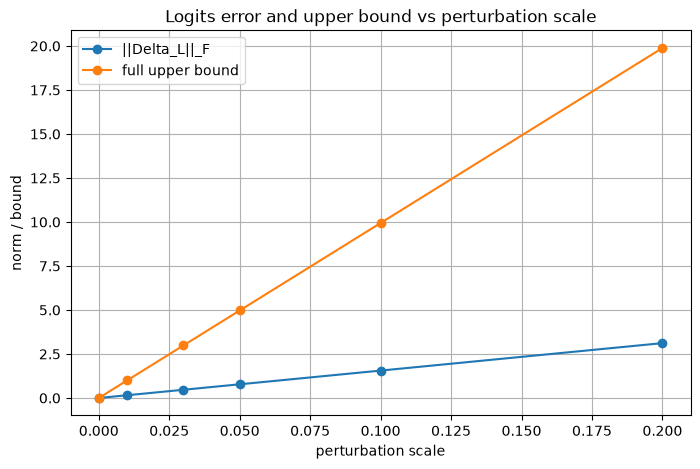

In [55]:
# TODO 6:
# 同じ perturbation direction に対して scale を複数変え、
# Delta_W1, Delta_Z1, Delta_H, Delta_L と最終上界を比較してください。
# 結果は表とグラフで確認してください。
import pandas as pd
import matplotlib.pyplot as plt

perturbation_direction = torch.randn(h, d, dtype=dtype, device=device)
scales = [0.0, 0.01, 0.03, 0.05, 0.1, 0.2]
scale_results = []

for scale in scales:
    delta_w1_scale = scale * perturbation_direction
    w1_tilde_scale = w1 + delta_w1_scale

    z1_tilde_scale = x @ w1_tilde_scale.T + b1
    delta_z1_scale = z1_tilde_scale - z1

    h_tilde_scale = torch.relu(z1_tilde_scale)
    delta_h_scale = h_tilde_scale - h_dense

    logits_tilde_scale = h_tilde_scale @ w2.T + b2
    delta_l_scale = logits_tilde_scale - logits

    delta_w1_scale_spectral = torch.linalg.matrix_norm(delta_w1_scale, ord=2)
    delta_z1_scale_fro = torch.linalg.vector_norm(delta_z1_scale)
    delta_h_scale_fro = torch.linalg.vector_norm(delta_h_scale)
    delta_l_scale_fro = torch.linalg.vector_norm(delta_l_scale)
    full_bound_scale = x_fro * delta_w1_scale_spectral * w2_spectral

    # 最終上界が 0 のときは、
    # ΔW1 = 0 なので ΔL = 0 でもある。
    # ただし actual / bound は 0 / 0 となり未定義である。
    # したがって 0.0 ではなく NaN を記録する。
    if full_bound_scale.item() == 0.0:
        actual_bound_ratio_scale = float("nan")
    else:
        actual_bound_ratio_scale = (
            delta_l_scale_fro / full_bound_scale
        ).item()

    scale_results.append(
        {
            "scale": scale,
            "delta_w1_spectral": float(delta_w1_scale_spectral),
            "delta_z1_fro": float(delta_z1_scale_fro),
            "delta_h_fro": float(delta_h_scale_fro),
            "delta_l_fro": float(delta_l_scale_fro),
            "full_upper_bound": float(full_bound_scale),
            "actual_bound_ratio": actual_bound_ratio_scale,
        }
    )

scale_df = pd.DataFrame(scale_results)

display(scale_df)

plt.figure(figsize=(8, 5))
plt.plot(
    scale_df["scale"],
    scale_df["delta_l_fro"],
    marker="o",
    label="||Delta_L||_F",
)
plt.plot(
    scale_df["scale"],
    scale_df["full_upper_bound"],
    marker="o",
    label="full upper bound",
)
plt.xlabel("perturbation scale")
plt.ylabel("norm / bound")
plt.title("Logits error and upper bound vs perturbation scale")
plt.legend()
plt.grid(True)
plt.show()


### ヒント

- perturbation direction $E$ は1回だけ作る
- `scales = [0.0, 0.01, 0.03, 0.05, 0.1, 0.2]`
- 各 scale で $\Delta W_1=\alpha E$ とする
- dense 側の `z1`, `h_dense`, `logits` は共通
- compressed 側だけ scale ごとに再計算する
- 最終上界と `actual / bound ratio` も記録する
- $\alpha=0$ では実測値・上界とも $0$ なので、ratio は $0/0$ で未定義である。表では `NaN` として扱う


### 検証


,scale,delta_w1_spectral,delta_z1_fro,delta_h_fro,delta_l_fro,full_upper_bound,actual_bound_ratio
0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.01,0.047625,0.115559,0.059680,0.155727,0.994283,0.156622
2,0.03,0.142876,0.346676,0.179041,0.467181,2.982848,0.156622
3,0.05,0.238127,0.577793,0.298401,0.778634,4.971414,0.156622
4,0.10,0.476254,1.155586,0.596802,1.557269,9.942828,0.156622
5,0.20,0.952507,2.311172,1.193608,3.117233,19.885655,0.156758


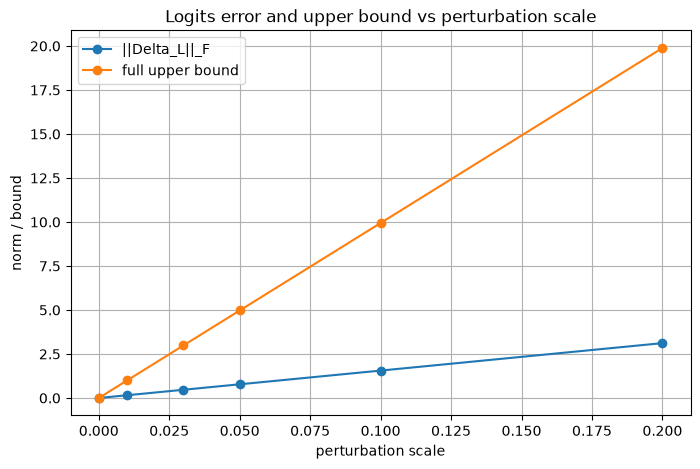

In [56]:
import math

assert len(scale_df) == len(scales)
assert list(scale_df["scale"]) == scales

for _, row in scale_df.iterrows():
    assert row["delta_h_fro"] <= (
        row["delta_z1_fro"] + inequality_atol
    )

    assert row["delta_l_fro"] <= (
        row["full_upper_bound"] + inequality_atol
    )

    # scale = 0 のとき ratio は 0/0 で NaN になる。
    # scale > 0 の場合だけ ratio <= 1 を確認する。
    if not math.isnan(row["actual_bound_ratio"]):
        assert row["actual_bound_ratio"] <= (
            1.0 + inequality_atol
        )

display(scale_df)

# 元仕様どおり、logits error と最終上界を中心に比較する。
plt.figure(figsize=(8, 5))
plt.plot(
    scale_df["scale"],
    scale_df["delta_l_fro"],
    marker="o",
    label="||Delta_L||_F",
)
plt.plot(
    scale_df["scale"],
    scale_df["full_upper_bound"],
    marker="o",
    label="full upper bound",
)
plt.xlabel("perturbation scale")
plt.ylabel("norm / bound")
plt.title("Logits error and upper bound vs perturbation scale")
plt.legend()
plt.grid(True)
plt.show()


## 11. 上界が loose になりやすい理由

この上界は worst-case bound です。

上界へ近づくには、

- $X$ が $\Delta W_1$ の最大増幅方向と整合する
- ReLU が誤差を減衰させない
- $\Delta H$ が $W_2$ の最大右特異ベクトル方向と整合する

といった条件が同時に強く成立する必要があります。

通常は完全には揃わないため、

$$
\|\Delta L\|_F
<
\|X\|_F\|\Delta W_1\|_2\|W_2\|_2
$$

となることが多いです。


## 12. TT 圧縮との対応

実際の TT 圧縮では、

$$
\Delta W_1
=
\widetilde W_1-W_1
$$

は TT-rank truncation による weight approximation error です。

今回の perturbation-scale 実験は TT-rank そのものではありませんが、

> weight approximation error が大きくなると forward error と上界がどう変化するか

を切り出して確認する toy experiment です。

実際の TT 実験では、`scale` の代わりに TT-rank を変え、
実際に得られた $\Delta W_1$ を使って同じ指標を比較できます。


## 13. まとめ

今回確認した流れは、

$$
\boxed{
\Delta W_1
\rightarrow
\Delta Z_1
\rightarrow
\Delta H
\rightarrow
\Delta L
}
$$

です。

第2 Linear では、

$$
\boxed{
\Delta L
=
\Delta H W_2^{\mathsf T}
}
$$

かつ、

$$
\boxed{
\|\Delta L\|_F
\le
\|\Delta H\|_F\|W_2\|_2
}
$$

です。

01・02と結合すると、

$$
\boxed{
\|\Delta L\|_F
\le
\|X\|_F
\|\Delta W_1\|_2
\|W_2\|_2
}
$$

となります。

さらに perturbation scale を変えることで、weight approximation error の増加が、
各段階の forward error と最終上界へどう現れるかを数値的に比較できます。

prediction / accuracy へ進むには、次に classification margin を扱います。
